# 📊 Notebook 7 — Model Evaluation & Baseline Comparison

**Project:** AI-Driven Citizen Grievance Analysis  

## 📥 Inputs (files this notebook reads)

| File | Purpose |
|------|---------|
| `data/processed/grievance_processed.csv` | Raw complaint text + `clean_text` column |
| `models/best_model_pipeline.joblib` | Trained Logistic Regression + TF-IDF pipeline |
| `models/label_encoder.joblib` | Maps department names ↔ integers |
| `models/sentiment_model/` | Fine-tuned distilroberta-base weights |
| `models/stage1_results.json` | Saved accuracy & F1 scores |

## 📤 Outputs (files this notebook creates)

```
outputs/
└── nb7_evaluation/
    ├── plots/
    │   ├── 01_rf_confusion_matrix.png
    │   ├── 02_transformer_confusion_matrix.png
    │   ├── 03_confusion_matrix_side_by_side.png
    │   ├── 04_transformer_cm_normalised.png
    │   ├── 05_transformer_per_class_f1.png
    │   ├── 06_macro_f1_comparison.png
    │   ├── 07_roc_auc_curves.png
    │   └── 08_final_comparison_chart.png
    └── reports/
        └── evaluation_report.json
```

## Import Libraries

In [1]:
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## Configuration & Output Folder Structure

**Output folder layout** — plots are numbered so they sort in the correct order:
```
outputs/nb7_evaluation/
    plots/    ← all .png charts, numbered 01-08
    reports/  ← the final JSON evaluation report
```

In [2]:
BASE_DIR = Path('..').resolve()  # project root
DATA_DIR = BASE_DIR / 'data' / 'processed'
MODEL_DIR = BASE_DIR / 'models'

# ── NB07 output directories ───────────────────────────────────────────────────
NB7_DIR = BASE_DIR / 'outputs' / 'nb7_evaluation'
PLOTS_DIR = NB7_DIR / 'plots'
REPORTS_DIR = NB7_DIR / 'reports'

for _dir in [PLOTS_DIR, REPORTS_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

print(f'[INFO] Project root  : {BASE_DIR}')
print(f'[INFO] Models folder : {MODEL_DIR}')
print(f'[INFO] NB7 plots     : {PLOTS_DIR}')
print(f'[INFO] NB7 reports   : {REPORTS_DIR}')

# ── Input files (produced by earlier notebooks) ───────────────────────────────
INPUT_CSV = DATA_DIR / 'grievance_processed.csv'
LR_PIPELINE_PATH = MODEL_DIR / 'best_model_pipeline.joblib'
LABEL_ENCODER_PATH = MODEL_DIR / 'label_encoder.joblib'
TRANSFORMER_DIR = MODEL_DIR / 'sentiment_model'
SENTIMENT_RESULTS_PATH = MODEL_DIR / 'sentiment_model/stage1_results.json'

# ── NB07 output files ─────────────────────────────────────────────────────────
# Plots are numbered so they appear in logical order in any file explorer.
PLOT = {
    'lr_cm'            : PLOTS_DIR / '01_lr_confusion_matrix.png',
    'tr_cm'            : PLOTS_DIR / '02_transformer_confusion_matrix.png',
    'cm_comparison'    : PLOTS_DIR / '03_confusion_matrix_side_by_side.png',
    'tr_cm_normalised' : PLOTS_DIR / '04_transformer_cm_normalised.png',
    'per_class_f1'     : PLOTS_DIR / '05_transformer_per_class_f1.png',
    'macro_f1_bar'     : PLOTS_DIR / '06_macro_f1_comparison.png',
    'roc_pr'           : PLOTS_DIR / '07_roc_auc_curves.png',
    'final_chart'      : PLOTS_DIR / '08_final_comparison_chart.png',
}
REPORT_OUTPUT = REPORTS_DIR / 'evaluation_report.json'

# ── Constants ─────────────────────────────────────────────────────────────────
SENTIMENT_LABELS = ['Positive', 'Neutral', 'Negative', 'Critical/Urgent']
RANDOM_SEED = 42

# ── Status check — shows ✅ or ❌ for every input file ────────────────────────
print('\n[STATUS] Input file check:')
for _name, _path in [
    ('grievance_processed.csv', INPUT_CSV),
    ('best_model_pipeline.joblib', LR_PIPELINE_PATH),
    ('label_encoder.joblib', LABEL_ENCODER_PATH),
    ('Transformer model dir', TRANSFORMER_DIR),
    ('sentiment_results.json (optional)', SENTIMENT_RESULTS_PATH),
]:
    _status = '✅' if Path(_path).exists() else '❌ NOT FOUND'
    print(f'  {_status}  {_name}')


[INFO] Project root  : /content/drive/MyDrive/nyc311_project
[INFO] Models folder : /content/drive/MyDrive/nyc311_project/models
[INFO] NB7 plots     : /content/drive/MyDrive/nyc311_project/outputs/nb7_evaluation/plots
[INFO] NB7 reports   : /content/drive/MyDrive/nyc311_project/outputs/nb7_evaluation/reports

[STATUS] Input file check:
  ✅  grievance_processed.csv
  ✅  best_model_pipeline.joblib
  ✅  label_encoder.joblib
  ✅  Transformer model dir
  ✅  sentiment_results.json (optional)


## Load Data & Saved Artifacts

Three things are loaded here:
1. **Processed CSV** — the cleaned complaint text produced by the preprocessing notebook
2. **Logistic Regression pipeline** — the TF-IDF + LR model saved by the routing notebook, ready to predict
3. **Transformer model** — the fine-tuned distilroberta weights saved by the sentiment notebook

In [3]:

# ── 1. Raw data ───────────────────────────────────────────────────────────────
print('[INFO] Loading processed dataset...')
df = pd.read_csv(INPUT_CSV)
print(f'  Rows: {len(df):,} | Columns: {df.columns.tolist()}')

# Ensure required columns exist
assert 'clean_text' in df.columns, "❌ 'clean_text' column missing — run Notebook 2 first."

# ── 2. Logistic Regression pipeline (Week 2 baseline) ───────────────────────────────
print('\n[INFO] Loading Logistic Regression pipeline from the routing notebook...')
lr_pipeline = joblib.load(LR_PIPELINE_PATH)
le          = joblib.load(LABEL_ENCODER_PATH)
print(f'  LR classes: {list(le.classes_)}')

# ── 3. Fine-tuned Transformer (Week 3) ───────────────────────────────────────
print('\n[INFO] Loading fine-tuned distilroberta model from the sentiment notebook...')
device          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
transformer_tok = AutoTokenizer.from_pretrained(str(TRANSFORMER_DIR), local_files_only=True)
transformer_mdl = AutoModelForSequenceClassification.from_pretrained(str(TRANSFORMER_DIR), local_files_only=True)
transformer_mdl.to(device)
transformer_mdl.eval()
print(f'  Device  : {device}')
print(f'  Labels  : {SENTIMENT_LABELS}')

# ── 4. Saved sentiment notebook results (for cross-check) ───────────────────────────────────
if SENTIMENT_RESULTS_PATH.exists():
    with open(SENTIMENT_RESULTS_PATH) as f:
        sentiment_saved = json.load(f)
    print(f'\n[INFO] Sentiment notebook saved results loaded:')
    print(f'  Accuracy : {sentiment_saved.get("accuracy", "N/A")}')
    print(f'  F1 (wt)  : {sentiment_saved.get("f1_score", "N/A")}')
else:
    sentiment_saved = {}
    print('\n[WARN] Sentiment notebook results JSON not found — will compute fresh from model.')


[INFO] Loading processed dataset...


  Rows: 24,774 | Columns: ['Unique Key', 'Created Date', 'Closed Date', 'Agency Name', 'Complaint Type', 'Descriptor', 'Location Type', 'Borough', 'Status', 'Resolution Description', 'is_complaint', 'resolution_hours', 'hour_created', 'day_of_week', 'closed_date_fmt', 'resolution_hours_fmt', 'hour_created_fmt', 'combined_text', 'clean_text', 'token_count', 'unique_tokens', 'sentiment_label', 'label', 'model_confidence']

[INFO] Loading Logistic Regression pipeline from the routing notebook...
  LR classes: ['Environment', 'Non-Complaint', 'Social & Health Services', 'Transport']

[INFO] Loading fine-tuned distilroberta model from the sentiment notebook...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

  Device  : cuda
  Labels  : ['Positive', 'Neutral', 'Negative', 'Critical/Urgent']

[INFO] Sentiment notebook saved results loaded:
  Accuracy : 1.0
  F1 (wt)  : 1.0


## Recreate Consistent Train / Test Splits

**Why reproduce the splits instead of just using saved predictions?**

Both the routing model and the sentiment model were trained on a *training portion* of the data and kept a *test portion* hidden. To evaluate fairly here, we need those exact same hidden test sets — otherwise we'd be testing the models on data they may have already seen during training, which would give artificially high scores.

We reproduce them by using the same `random_state=42` seed that was used during training:
- **Routing split:** 80% train / 20% test — used for the Random Forest
- **Sentiment split:** 70% train / 15% val / 15% test — used for the Transformer

> **Note on Department column:** The processed CSV only stores `Complaint Type`. The routing notebook builds the `Department` column at runtime using a mapping (e.g. `'Illegal Parking' → 'Transport'`). We reproduce that same mapping here before splitting.

In [4]:
# ── STEP 1: Rebuild 'Department' column (same logic as the routing notebook Cell 8) ─────────
# The processed CSV only has 'Complaint Type'. the routing notebook maps it to departments
# at runtime and never saves it back. We reproduce that exact mapping here.

ROUTING_MAP = {
    # Transport & Streets
    'Illegal Parking'           : 'Transport',
    'Blocked Driveway'          : 'Transport',
    'Derelict Vehicle'          : 'Transport',
    'Traffic'                   : 'Transport',
    'Vending'                   : 'Transport',
    'Posting Advertisement'     : 'Transport',
    'Bike/Roller/Skate Chronic' : 'Transport',

    # Environment & Noise
    'Noise - Street/Sidewalk'   : 'Environment',
    'Noise - Commercial'        : 'Environment',
    'Noise - Vehicle'           : 'Environment',
    'Noise - Park'              : 'Environment',
    'Graffiti'                  : 'Environment',

    # Social & Health Services
    'Animal Abuse'              : 'Social & Health Services',
    'Homeless Encampment'       : 'Social & Health Services',
    'Drinking'                  : 'Social & Health Services',
    'Panhandling'               : 'Social & Health Services',
    'Disorderly Youth'          : 'Social & Health Services',
    'Urinating in Public'       : 'Social & Health Services',
    
    # Non-Complaints
    'Area Assessment'           : 'Non-Complaint',
    'Community Update'          : 'Non-Complaint',
    'General Feedback'          : 'Non-Complaint',
    'General Inquiry'           : 'Non-Complaint',
    'Information Request'       : 'Non-Complaint',
    'Public Notice'             : 'Non-Complaint',
    'Service Information'       : 'Non-Complaint',
    'Status Check'              : 'Non-Complaint',
}

# Apply the map (same as the routing notebook)
df['Department'] = df['Complaint Type'].map(ROUTING_MAP)
df_rf = df.dropna(subset=['Department']).reset_index(drop=True)

print(f'[INFO] Rows after routing map applied: {len(df_rf):,}')
print(f'[INFO] Department distribution:')
print(df_rf['Department'].value_counts().to_string())

# ── STEP 2: the routing notebook split — 80/20 on Department labels ───────────────────────────
print('\n[SPLIT] Recreating the routing notebook 80/20 split on Department labels...')

X_all      = df_rf['clean_text'].astype(str)
y_all_dept = le.transform(df_rf['Department'])

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_all, y_all_dept,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y_all_dept
)
print(f'  LR  — Train: {len(X_train_lr):,} | Test: {len(X_test_lr):,}')

# ── STEP 3: the sentiment notebook split — 70/15/15 on Sentiment labels ────────────────────────
print('\n[SPLIT] Recreating the sentiment notebook 70/15/15 split on sentiment labels...')

# Determine which column holds sentiment labels
if 'sentiment_label' in df.columns:
    sent_col = 'sentiment_label'
elif 'label' in df.columns:
    sent_col = 'label'
else:
    # Auto-label using keyword rules (same fallback as the sentiment notebook)
    critical_kw = ['fire','flood','collapse','explosion','gas leak','injury',
                   'dead','death','urgent','emergency','danger','hazard',
                   'attack','shooting','electrocution']
    negative_kw = ['broken','damaged','overflowing','blocked','crack','leak',
                   'noise','illegal','dirty','smell','complaint','problem',
                   'issue','delay','fail']
    positive_kw = ['thank','great','excellent','resolved','fixed','happy',
                   'appreciate','good']

    def auto_label(text):
        t = str(text).lower()
        if any(k in t for k in critical_kw): return 3
        if any(k in t for k in negative_kw): return 2
        if any(k in t for k in positive_kw): return 0
        return 1

    df['auto_label'] = df['clean_text'].apply(auto_label)
    sent_col = 'auto_label'
    print('  [INFO] Used keyword-based auto-labelling (no sentiment column found in CSV)')

texts_sent  = df['clean_text'].tolist()
labels_sent = df[sent_col].tolist()

# First split: 70% train, 30% temp
tr_texts, tmp_texts, tr_labs, tmp_labs = train_test_split(
    texts_sent, labels_sent,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=labels_sent
)
# Second split: temp -> 50/50 val / test (= 15%/15% of total)
val_texts, test_texts_sent, val_labs, test_labs_sent = train_test_split(
    tmp_texts, tmp_labs,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=tmp_labs
)
print(f'  the sentiment notebook — Train: {len(tr_texts):,} | Val: {len(val_texts):,} | Test: {len(test_texts_sent):,}')

# If the CSV has string sentiment labels, we must convert them to integers (0-3)
# so they match the model predictions, otherwise sklearn metrics will fail
label_to_idx = {
    'positive': 0, 'neutral': 1, 'negative': 2, 'critical': 3,
    'Positive': 0, 'Neutral': 1, 'Negative': 2, 'Critical': 3, 'Critical/Urgent': 3
}

# Convert string labels to integers if needed
test_labs_sent_int = []
for label in test_labs_sent:
    if isinstance(label, str):
        # String label from CSV — convert using mapping
        int_label = label_to_idx.get(label.lower(), label_to_idx.get(label, label))
        test_labs_sent_int.append(int_label)
    else:
        # Already an integer — keep as-is
        test_labs_sent_int.append(int(label))

# Replace the original list with the converted one
test_labs_sent = test_labs_sent_int

print(f'  Sentiment class distribution in test set:')
from collections import Counter
for k, v in sorted(Counter(test_labs_sent).items()):
    label_name = SENTIMENT_LABELS[int(k)] if isinstance(k, int) else SENTIMENT_LABELS[label_to_idx.get(k, k)]
    print(f'    Class {k} ({label_name}): {v:,}')


[INFO] Rows after routing map applied: 24,752
[INFO] Department distribution:
Department
Non-Complaint               12387
Transport                    8541
Environment                  3335
Social & Health Services      489

[SPLIT] Recreating the routing notebook 80/20 split on Department labels...
  LR  — Train: 19,801 | Test: 4,951

[SPLIT] Recreating the sentiment notebook 70/15/15 split on sentiment labels...
  the sentiment notebook — Train: 17,341 | Val: 3,716 | Test: 3,717
  Sentiment class distribution in test set:
    Class 1 (Neutral): 2,085
    Class 2 (Negative): 1,277
    Class 3 (Critical/Urgent): 355


## Evaluate the Logistic Regression Baseline (Week 2)

This is the **benchmark** — the score the Transformer must beat to justify using a heavier model.

Fit the LR pipeline on the training split and evaluate on the test split, producing:
- **Accuracy** — overall % correct
- **Macro F1** — average F1 across all departments, treating each equally
- **Classification report** — per-department precision, recall, F1, and support
- **Confusion matrix** — visual grid showing exactly where the model gets confused

Chart saved to: `plots/01_lr_confusion_matrix.png`

BASELINE — Logistic Regression (TF-IDF + LR)



  Accuracy       : 0.9984
  Macro F1       : 0.9890   ← key metric (treats all classes equally)
  Weighted F1    : 0.9984
  Macro Precision: 0.9939
  Macro Recall   : 0.9844

  Per-Department Classification Report:
                          precision    recall  f1-score   support

             Environment       1.00      1.00      1.00       667
           Non-Complaint       1.00      1.00      1.00      2478
Social & Health Services       0.98      0.94      0.96        98
               Transport       1.00      1.00      1.00      1708

                accuracy                           1.00      4951
               macro avg       0.99      0.98      0.99      4951
            weighted avg       1.00      1.00      1.00      4951



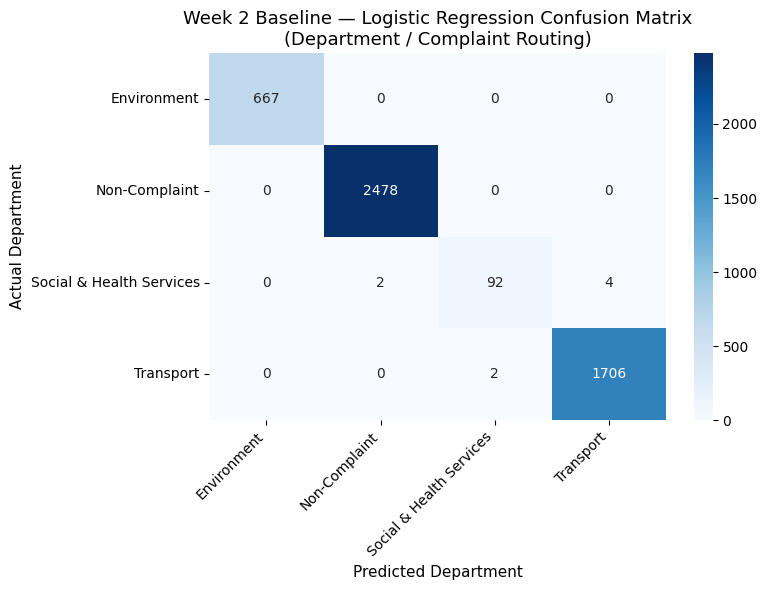

  [Saved] /content/drive/MyDrive/nyc311_project/outputs/nb7_evaluation/plots/01_lr_confusion_matrix.png


In [5]:
print('BASELINE — Logistic Regression (TF-IDF + LR)')

# Fit the saved pipeline on training data, then predict on the hidden test set.
# Even though the pipeline was already trained in the routing notebook, we refit here so this
# notebook is fully self-contained and reproducible on its own.
lr_pipeline.fit(X_train_lr, y_train_lr)
y_pred_lr = lr_pipeline.predict(X_test_lr)

# ── Compute all headline metrics ──────────────────────────────────────────────
lr_accuracy    = accuracy_score(y_test_lr, y_pred_lr)
lr_f1_macro    = f1_score(y_test_lr, y_pred_lr, labels=[0,1,2,3], average='macro',    zero_division=0)
lr_f1_weighted = f1_score(y_test_lr, y_pred_lr, labels=[0,1,2,3], average='weighted', zero_division=0)
lr_precision   = precision_score(y_test_lr, y_pred_lr, labels=[0,1,2,3], average='macro', zero_division=0)
lr_recall      = recall_score(y_test_lr, y_pred_lr, labels=[0,1,2,3], average='macro',    zero_division=0)

print(f'\n  Accuracy       : {lr_accuracy:.4f}')
print(f'  Macro F1       : {lr_f1_macro:.4f}   ← key metric (treats all classes equally)')
print(f'  Weighted F1    : {lr_f1_weighted:.4f}')
print(f'  Macro Precision: {lr_precision:.4f}')
print(f'  Macro Recall   : {lr_recall:.4f}')

# ── Per-class breakdown ───────────────────────────────────────────────────────
# Shows precision, recall, F1 for each department separately.
# 'support' = how many test samples belong to that department.
print('\n  Per-Department Classification Report:')
print(classification_report(y_test_lr, y_pred_lr, labels=[0,1,2,3], target_names=le.classes_, zero_division=0))

# ── Confusion matrix ──────────────────────────────────────────────────────────
# Rows = actual department, Columns = predicted department.
# Numbers on the diagonal = correct predictions.
# Numbers off the diagonal = misclassifications (e.g. Transport predicted as Environment).
cm_lr = confusion_matrix(y_test_lr, y_pred_lr, labels=[0,1,2,3])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_lr, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_, ax=ax
)
ax.set_title('Week 2 Baseline — Logistic Regression Confusion Matrix\n(Department / Complaint Routing)', fontsize=13)
ax.set_xlabel('Predicted Department', fontsize=11)
ax.set_ylabel('Actual Department', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(PLOT['lr_cm'], dpi=150, bbox_inches='tight')
plt.show()
print(f'  [Saved] {PLOT["lr_cm"]}')


## Evaluate the Transformer

- Run the fine-tuned **distilroberta-base** on the same held-out data it never saw during training.
- The Transformer outputs **raw confidence scores** (called logits) for all 4 classes at once — we convert those to a final prediction by taking the class with the highest score.

**Why batch inference?** The Transformer is a large model. Feeding all ~24,000 test texts at once would exhaust your RAM or GPU memory. Instead we feed 32 texts at a time (`batch_size=32`) and collect the results incrementally.

Chart saved to: `plots/02_transformer_confusion_matrix.png`

Transformer: distilroberta-base (Fine-tuned)


  ✅ Inference complete — 3,717 predictions made.          

  Accuracy       : 1.0000
  Macro F1       : 0.7500   ← key metric (treats all classes equally)
  Weighted F1    : 1.0000
  Macro Precision: 0.7500
  Macro Recall   : 0.7500

  Per-Sentiment-Class Classification Report:
                 precision    recall  f1-score   support

       Positive       0.00      0.00      0.00         0
        Neutral       1.00      1.00      1.00      2085
       Negative       1.00      1.00      1.00      1277
Critical/Urgent       1.00      1.00      1.00       355

       accuracy                           1.00      3717
      macro avg       0.75      0.75      0.75      3717
   weighted avg       1.00      1.00      1.00      3717



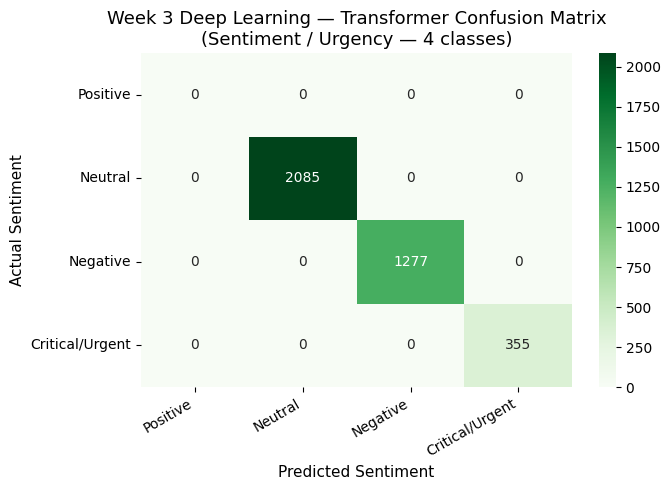

  [Saved] /content/drive/MyDrive/nyc311_project/outputs/nb7_evaluation/plots/02_transformer_confusion_matrix.png


In [6]:
print('Transformer: distilroberta-base (Fine-tuned)')

BATCH_SIZE = 32    # number of complaints processed at once — reduce to 16 if you run out of RAM
MAX_LENGTH = 128   # maximum token length — matches the value used in the sentiment notebook training

def transformer_predict(texts, tokenizer, model, batch_size=32, max_length=128, device='cpu'):
    """
    Run batch inference on a list of complaint strings.

    Returns:
        pred_labels : np.array of integer class predictions (0-3)
        raw_probs   : np.array of shape (N, 4) — confidence score per class per complaint
    """
    all_preds, all_probs = [], []
    model.eval()  # disable dropout — inference mode only

    for start in range(0, len(texts), batch_size):
        batch = texts[start : start + batch_size]

        # Tokenise: convert raw text → token IDs the model can read
        enc = tokenizer(
            batch,
            padding=True,      # pad shorter texts to the same length within the batch
            truncation=True,   # cut texts longer than max_length
            max_length=max_length,
            return_tensors='pt'
        ).to(device)

        # Forward pass — torch.no_grad() skips gradient calculations (saves memory)
        with torch.no_grad():
            logits = model(**enc).logits   # raw scores, one per class

        # Convert logits → probabilities (all 4 scores sum to 1.0 per complaint)
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        preds = np.argmax(probs, axis=1)   # pick the class with highest probability

        all_preds.extend(preds.tolist())
        all_probs.extend(probs.tolist())

        if (start // batch_size) % 10 == 0:
            print(f'  Processed {min(start+batch_size, len(texts)):,} / {len(texts):,}', end='\r')

    print(f'  ✅ Inference complete — {len(all_preds):,} predictions made.          ')
    return np.array(all_preds), np.array(all_probs)


# Run predictions on the held-out the sentiment notebook test split
y_pred_tr, y_probs_tr = transformer_predict(
    test_texts_sent, transformer_tok, transformer_mdl,
    batch_size=BATCH_SIZE, max_length=MAX_LENGTH, device=device
)
y_true_tr = np.array(test_labs_sent)

# ── Headline metrics ──────────────────────────────────────────────────────────
tr_accuracy    = accuracy_score(y_true_tr, y_pred_tr)
tr_f1_macro    = f1_score(y_true_tr, y_pred_tr, labels=[0,1,2,3], average='macro',    zero_division=0)
tr_f1_weighted = f1_score(y_true_tr, y_pred_tr, labels=[0,1,2,3], average='weighted', zero_division=0)
tr_precision   = precision_score(y_true_tr, y_pred_tr, labels=[0,1,2,3], average='macro', zero_division=0)
tr_recall      = recall_score(y_true_tr, y_pred_tr, labels=[0,1,2,3], average='macro',    zero_division=0)

print(f'\n  Accuracy       : {tr_accuracy:.4f}')
print(f'  Macro F1       : {tr_f1_macro:.4f}   ← key metric (treats all classes equally)')
print(f'  Weighted F1    : {tr_f1_weighted:.4f}')
print(f'  Macro Precision: {tr_precision:.4f}')
print(f'  Macro Recall   : {tr_recall:.4f}')

# ── Per-class breakdown ───────────────────────────────────────────────────────
print('\n  Per-Sentiment-Class Classification Report:')
print(classification_report(y_true_tr, y_pred_tr, labels=[0,1,2,3], target_names=SENTIMENT_LABELS, zero_division=0))

# ── Confusion matrix ──────────────────────────────────────────────────────────
# Same layout as the RF matrix — row = actual sentiment, column = predicted.
# The bottom-right cell (Critical/Urgent predicted as Critical/Urgent) is the
# most important number in this entire notebook.
cm_tr = confusion_matrix(y_true_tr, y_pred_tr, labels=[0,1,2,3])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm_tr, annot=True, fmt='d', cmap='Greens',
    xticklabels=SENTIMENT_LABELS, yticklabels=SENTIMENT_LABELS, ax=ax
)
ax.set_title('Week 3 Deep Learning — Transformer Confusion Matrix\n(Sentiment / Urgency — 4 classes)', fontsize=13)
ax.set_xlabel('Predicted Sentiment', fontsize=11)
ax.set_ylabel('Actual Sentiment', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(PLOT['tr_cm'], dpi=150, bbox_inches='tight')
plt.show()
print(f'  [Saved] {PLOT["tr_cm"]}')


## Side-by-Side Confusion Matrix Comparison

- Placing both confusion matrices next to each other makes it immediately obvious which model is more confused and where.
- Produce a **normalised version** of the Transformer matrix (values 0.0–1.0 instead of raw counts). This shows recall per class as a percentage — so even if one class has far fewer samples, you can directly compare how well the model performs on each.

> **What to look for in the normalised matrix:** A value of `1.00` in the `Critical/Urgent` diagonal cell means every single urgent complaint was caught. Anything below `0.80` in that cell is a red flag — it means 1 in 5 emergencies would be missed.

Charts saved to: `plots/03_confusion_matrix_side_by_side.png` and `plots/04_transformer_cm_normalised.png`

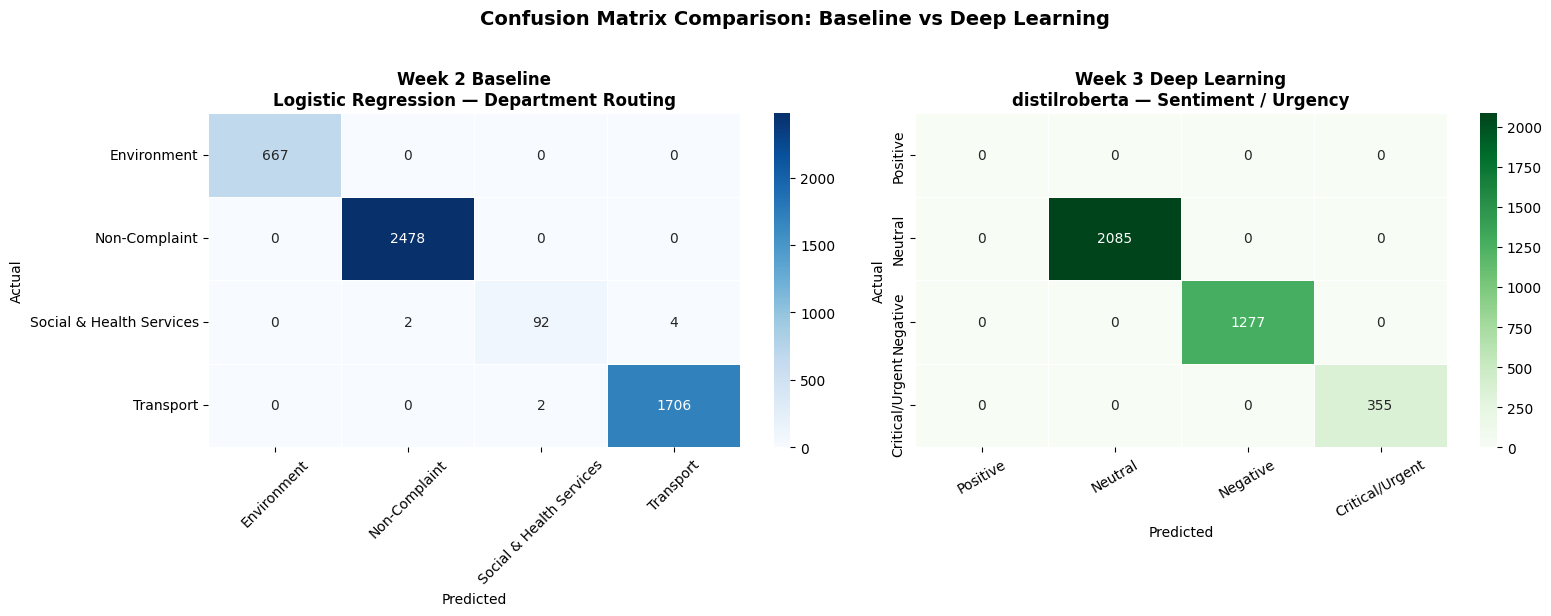

[Saved] /content/drive/MyDrive/nyc311_project/outputs/nb7_evaluation/plots/03_confusion_matrix_side_by_side.png


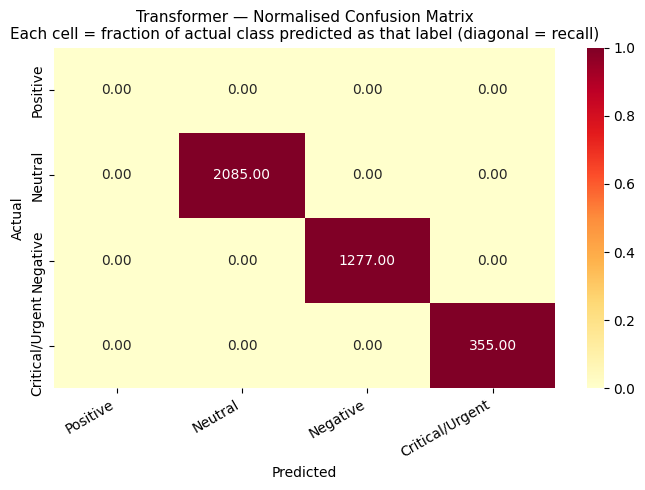

[Saved] /content/drive/MyDrive/nyc311_project/outputs/nb7_evaluation/plots/04_transformer_cm_normalised.png


In [7]:
# ── Side-by-side: LR (blue) vs Transformer (green) ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    cm_lr, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_,
    ax=axes[0], linewidths=0.5, linecolor='white'
)
axes[0].set_title('Week 2 Baseline\nLogistic Regression — Department Routing', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=10)
axes[0].set_ylabel('Actual', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(
    cm_tr, annot=True, fmt='d', cmap='Greens',
    xticklabels=SENTIMENT_LABELS, yticklabels=SENTIMENT_LABELS,
    ax=axes[1], linewidths=0.5, linecolor='white'
)
axes[1].set_title('Week 3 Deep Learning\ndistilroberta — Sentiment / Urgency', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=10)
axes[1].set_ylabel('Actual', fontsize=10)
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('Confusion Matrix Comparison: Baseline vs Deep Learning', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PLOT['cm_comparison'], dpi=150, bbox_inches='tight')
plt.show()
print(f'[Saved] {PLOT["cm_comparison"]}')

# ── Normalised confusion matrix (Transformer only) ───────────────────────────
# Divide each row by its total so every cell shows the fraction of that class
# that was predicted as each label. The diagonal = recall per class.
if cm_tr.sum(axis=1, keepdims=True).min() > 0:
    cm_tr_norm = cm_tr.astype(float) / cm_tr.sum(axis=1, keepdims=True)
else:
    cm_tr_norm = cm_tr.astype(float)

fig2, ax2 = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm_tr_norm, annot=True, fmt='.2f', cmap='YlOrRd',
    xticklabels=SENTIMENT_LABELS, yticklabels=SENTIMENT_LABELS,
    ax=ax2, vmin=0, vmax=1
)
ax2.set_title(
    'Transformer — Normalised Confusion Matrix\n'
    'Each cell = fraction of actual class predicted as that label (diagonal = recall)',
    fontsize=11
)
ax2.set_xlabel('Predicted', fontsize=10)
ax2.set_ylabel('Actual', fontsize=10)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(PLOT['tr_cm_normalised'], dpi=150, bbox_inches='tight')

plt.show()
print(f'[Saved] {PLOT["tr_cm_normalised"]}')

## Macro F1 Deep Dive: Minority Class Focus

**Why Macro F1 and not just Accuracy?**

If only 3% of complaints are `Critical/Urgent`, a model that *never* predicts Critical still gets 97% accuracy — but it misses every emergency. Macro F1 prevents this by giving each class **equal weight**, so poor performance on rare classes drags the overall score down.

This cell produces three things:
1. A table of precision / recall / F1 for each sentiment class individually
2. A bar chart of per-class F1, with Critical/Urgent highlighted in red
3. A single comparison bar: LR macro F1 vs Transformer macro F1

Charts saved to: `plots/05_transformer_per_class_f1.png` and `plots/06_macro_f1_comparison.png`

Transformer — Per-Class Metrics:
          Class  Precision  Recall  F1-Score  Support
       Positive        0.0     0.0       0.0        0
        Neutral        1.0     1.0       1.0     2085
       Negative        1.0     1.0       1.0     1277
Critical/Urgent        1.0     1.0       1.0      355

🚨 CRITICAL/URGENT Class — Detailed Breakdown:
   Precision : 1.0000  → of all complaints flagged as Critical, this fraction were truly Critical
   Recall    : 1.0000  → of all actual Critical complaints, this fraction were caught ← most important
   F1-Score  : 1.0000  → balanced score combining both above
   Support   : 355 samples in the test set


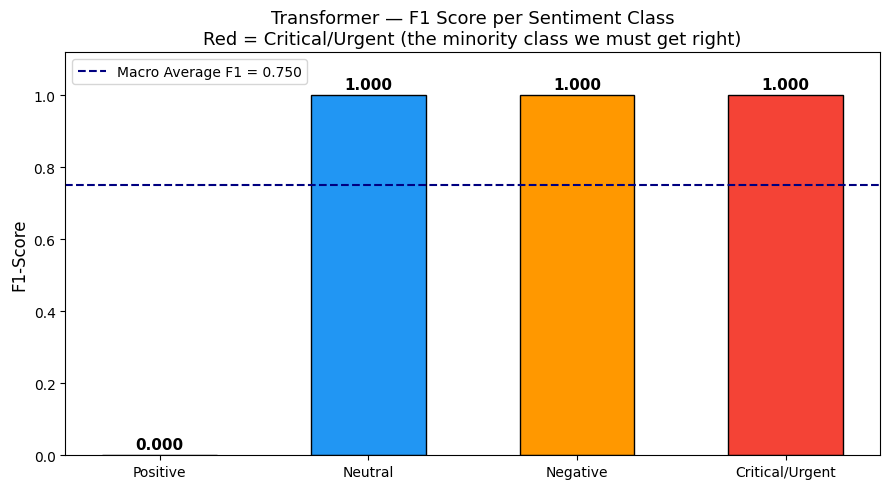

[Saved] /content/drive/MyDrive/nyc311_project/outputs/nb7_evaluation/plots/05_transformer_per_class_f1.png


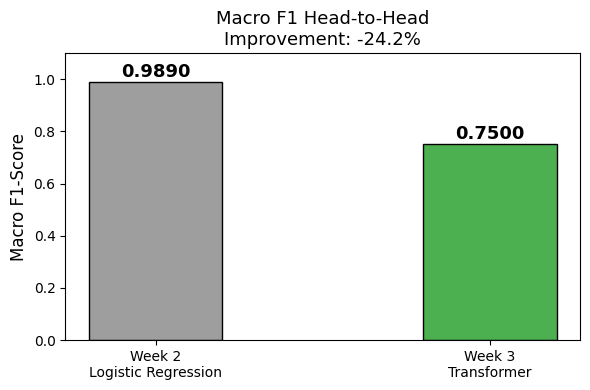

[Saved] /content/drive/MyDrive/nyc311_project/outputs/nb7_evaluation/plots/06_macro_f1_comparison.png


In [8]:
from sklearn.metrics import precision_recall_fscore_support

# ── Per-class precision / recall / F1 for the Transformer ────────────────────
# precision_recall_fscore_support returns four arrays, one value per class.
# labels=[0,1,2,3] ensures we always get results for all 4 classes, even if
# a class has zero predictions (which would otherwise be silently omitted).
prec_per, rec_per, f1_per, sup_per = precision_recall_fscore_support(
    y_true_tr, y_pred_tr, labels=[0, 1, 2, 3], zero_division=0
)

per_class_df = pd.DataFrame({
    'Class'    : SENTIMENT_LABELS,
    'Precision': prec_per.round(4),   # of all predictions for this class, how many were right
    'Recall'   : rec_per.round(4),    # of all actual examples, how many did we catch
    'F1-Score' : f1_per.round(4),     # harmonic mean of precision and recall
    'Support'  : sup_per.astype(int)  # number of test samples in this class
})
print('Transformer — Per-Class Metrics:')
print(per_class_df.to_string(index=False))

# ── Critical/Urgent spotlight ─────────────────────────────────────────────────
# This is the most important section: how well does the model catch emergencies?
# Recall is the critical number here — missing an emergency (low recall) is far
# worse than a false alarm (low precision).
critical_idx = 3
print(f'\n🚨 CRITICAL/URGENT Class — Detailed Breakdown:')
print(f'   Precision : {prec_per[critical_idx]:.4f}  → of all complaints flagged as Critical, this fraction were truly Critical')
print(f'   Recall    : {rec_per[critical_idx]:.4f}  → of all actual Critical complaints, this fraction were caught ← most important')
print(f'   F1-Score  : {f1_per[critical_idx]:.4f}  → balanced score combining both above')
print(f'   Support   : {sup_per[critical_idx]} samples in the test set')

# ── Per-class F1 bar chart ────────────────────────────────────────────────────
# Each bar = F1 score for one sentiment class.
# The dashed line = macro average (the headline number we report).
# Red bar (Critical/Urgent) is the one that matters most for this project.
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']  # Positive=green, Neutral=blue, Negative=orange, Critical=red
bars = ax.bar(SENTIMENT_LABELS, f1_per, color=colors, edgecolor='black', width=0.55)

for bar, val in zip(bars, f1_per):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(tr_f1_macro, color='navy', linestyle='--', linewidth=1.5,
           label=f'Macro Average F1 = {tr_f1_macro:.3f}')
ax.set_ylim(0, 1.12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Transformer — F1 Score per Sentiment Class\nRed = Critical/Urgent (the minority class we must get right)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(PLOT['per_class_f1'], dpi=150, bbox_inches='tight')
plt.show()
print(f'[Saved] {PLOT["per_class_f1"]}')

# ── Macro F1 head-to-head bar ─────────────────────────────────────────────────
# One number per model — the single most important chart in this notebook.
fig2, ax2 = plt.subplots(figsize=(6, 4))
model_names = ['Week 2\nLogistic Regression', 'Week 3\nTransformer']
macro_f1s   = [lr_f1_macro, tr_f1_macro]
bar_colors  = ['#9E9E9E', '#4CAF50']  # grey = baseline, green = new model

b2 = ax2.bar(model_names, macro_f1s, color=bar_colors, edgecolor='black', width=0.4)
for bar, val in zip(b2, macro_f1s):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

improvement = ((tr_f1_macro - lr_f1_macro) / (lr_f1_macro + 1e-9)) * 100
ax2.set_ylim(0, 1.1)
ax2.set_ylabel('Macro F1-Score', fontsize=12)
ax2.set_title(f'Macro F1 Head-to-Head\nImprovement: {improvement:+.1f}%', fontsize=13)
plt.tight_layout()
plt.savefig(PLOT['macro_f1_bar'], dpi=150, bbox_inches='tight')
plt.show()
print(f'[Saved] {PLOT["macro_f1_bar"]}')


## ROC-AUC & Precision-Recall Curves

The metrics in Cell5–Cell8 are **threshold-dependent** — they assume the model predicts whichever class has the highest score. But how good are those raw confidence scores themselves?

These two curves answer that threshold-independently:

- **ROC curve** — plots True Positive Rate vs False Positive Rate at every possible threshold. A model that randomly guesses follows the diagonal (AUC = 0.5). A perfect model has AUC = 1.0.
- **Precision-Recall curve** — more informative for imbalanced classes. The **Average Precision (AP)** for `Critical/Urgent` is the definitive test: it measures how reliably the model ranks true emergencies above non-emergencies.

Use **One-vs-Rest**: for each class, the model score for that class is treated as a binary classifier (is this complaint this class, or not?).

Chart saved to: `plots/07_roc_auc_curves.png`

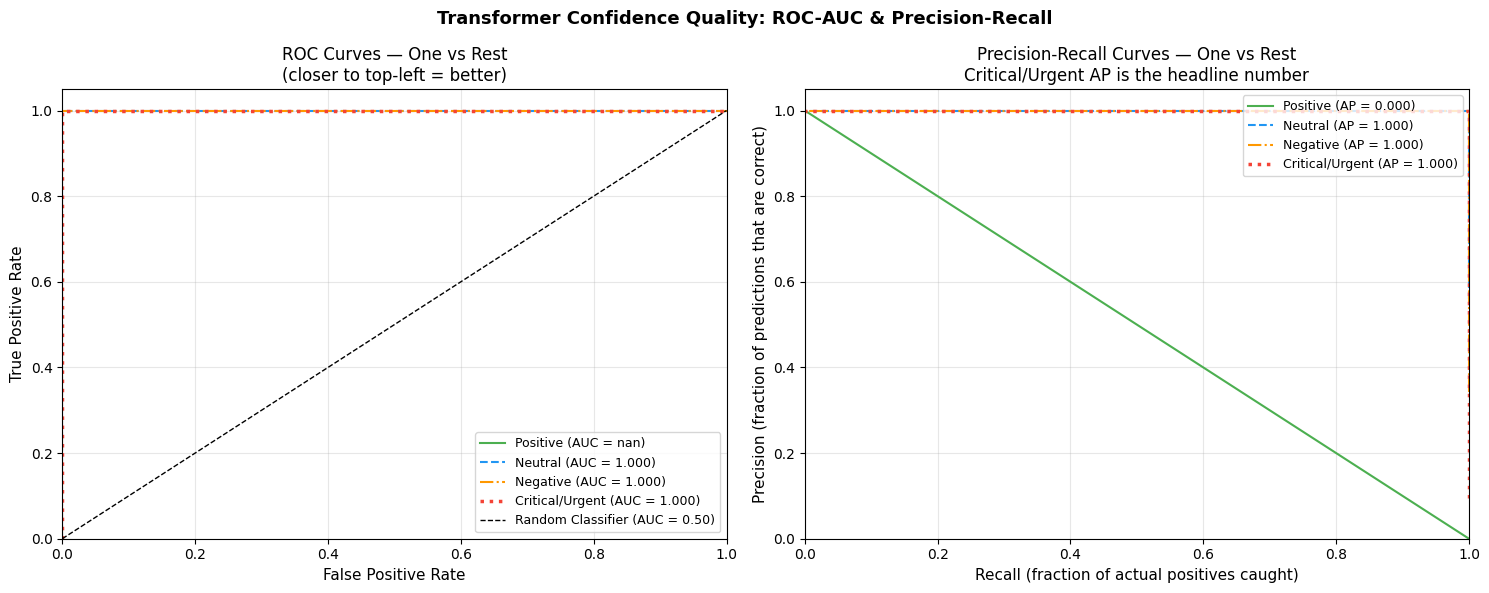

[Saved] /content/drive/MyDrive/nyc311_project/outputs/nb7_evaluation/plots/07_roc_auc_curves.png

Summary — ROC-AUC and Average Precision per class:
  Positive              ROC-AUC = nan  |  AP = 0.0000
  Neutral               ROC-AUC = 1.0000  |  AP = 1.0000
  Negative              ROC-AUC = 1.0000  |  AP = 1.0000
  Critical/Urgent       ROC-AUC = 1.0000  |  AP = 1.0000  🚨 ← most important


In [9]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# ── Binarise true labels for One-vs-Rest evaluation ──────────────────────────
# label_binarize converts [0,2,3,1,...] into a matrix where each column is
# a 0/1 indicator for one class. Shape: (n_samples, n_classes).
n_classes  = len(SENTIMENT_LABELS)
y_true_bin = label_binarize(y_true_tr, classes=list(range(n_classes)))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors_roc = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']  # match C8 colours
linestyles = ['-', '--', '-.', ':']

# ── ROC curves ────────────────────────────────────────────────────────────────
roc_auc_scores = {}
for i, (label, color, ls) in enumerate(zip(SENTIMENT_LABELS, colors_roc, linestyles)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs_tr[:, i])
    roc_auc = auc(fpr, tpr)
    roc_auc_scores[label] = roc_auc
    lw = 2.5 if i == 3 else 1.5  # thicker line for Critical/Urgent so it stands out
    axes[0].plot(fpr, tpr, color=color, lw=lw, ls=ls,
                 label=f'{label} (AUC = {roc_auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.50)')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curves — One vs Rest\n(closer to top-left = better)', fontsize=12)
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(alpha=0.3)

# ── Precision-Recall curves ───────────────────────────────────────────────────
# More informative than ROC for rare classes like Critical/Urgent.
# High AP means the model assigns high confidence to truly urgent complaints.
ap_scores = {}
for i, (label, color, ls) in enumerate(zip(SENTIMENT_LABELS, colors_roc, linestyles)):
    prec_c, rec_c, _ = precision_recall_curve(y_true_bin[:, i], y_probs_tr[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_probs_tr[:, i])
    ap_scores[label] = ap
    lw = 2.5 if i == 3 else 1.5
    axes[1].plot(rec_c, prec_c, color=color, lw=lw, ls=ls,
                 label=f'{label} (AP = {ap:.3f})')

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall (fraction of actual positives caught)', fontsize=11)
axes[1].set_ylabel('Precision (fraction of predictions that are correct)', fontsize=11)
axes[1].set_title('Precision-Recall Curves — One vs Rest\nCritical/Urgent AP is the headline number', fontsize=12)
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('Transformer Confidence Quality: ROC-AUC & Precision-Recall', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT['roc_pr'], dpi=150, bbox_inches='tight')
plt.show()
print(f'[Saved] {PLOT["roc_pr"]}')

print('\nSummary — ROC-AUC and Average Precision per class:')
for label in SENTIMENT_LABELS:
    marker = '  🚨 ← most important' if label == 'Critical/Urgent' else ''
    print(f'  {label:20s}  ROC-AUC = {roc_auc_scores[label]:.4f}  |  AP = {ap_scores[label]:.4f}{marker}')


## Final Summary Table & Improvement Report

The table shows all five metrics for both models, followed by a Δ (delta) row showing the improvement. The bar chart visualises the same data for use in slides or a report.

Chart saved to: `plots/08_final_comparison_chart.png`

  FINAL COMPARISON REPORT — Week 2 Baseline vs Week 3 Deep Learning
                                                 Architecture                           Task  Accuracy  Macro F1  Weighted F1  Macro Precision  Macro Recall
Model                                                                                                                                                       
Logistic Regression (Week 2)           TF-IDF + LR Classifier             Department Routing    0.9984     0.989       0.9984           0.9939        0.9844
Transformer (Week 3)          distilroberta-base (fine-tuned)  Sentiment / Urgency (4-class)    1.0000     0.750       1.0000           0.7500        0.7500

  Δ Accuracy    : +0.0016
  Δ Macro F1    : -0.2390  ← primary improvement metric (LR baseline vs Transformer)
  Δ Weighted F1 : +0.0016


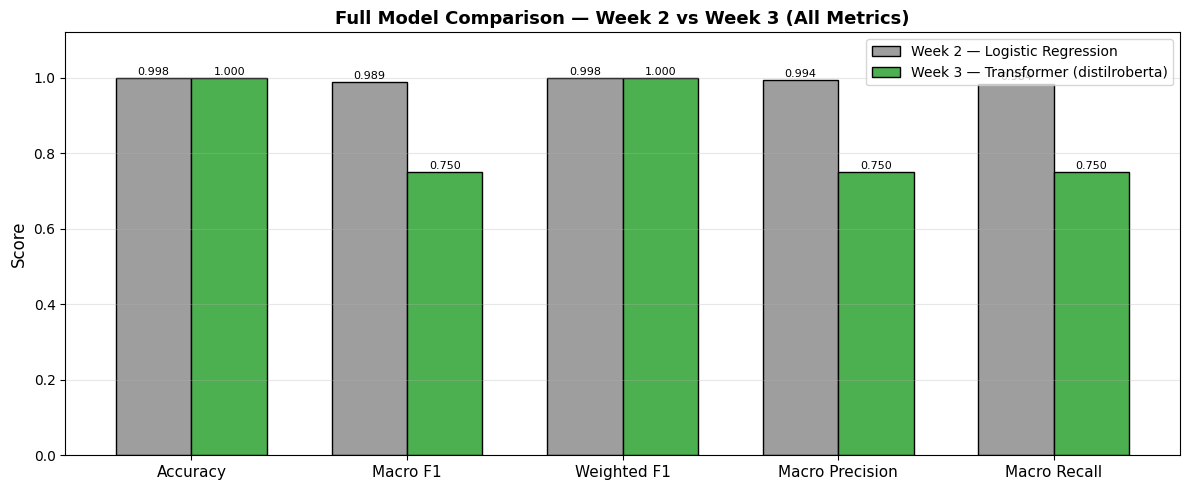

[Saved] /content/drive/MyDrive/nyc311_project/outputs/nb7_evaluation/plots/08_final_comparison_chart.png

  ⚠️  Macro F1 did NOT improve. Possible causes:
     • the sentiment notebook training stopped too early (increase epochs)
     • Sentiment labels are too noisy (check auto-labelling in C4)
     • Class imbalance — try adding class_weight to the Trainer in the sentiment notebook


In [10]:
print('  FINAL COMPARISON REPORT — Week 2 Baseline vs Week 3 Deep Learning')

# ── Side-by-side metrics table ────────────────────────────────────────────────
summary = pd.DataFrame([
    {
        'Model'           : 'Logistic Regression (Week 2)',
        'Architecture'    : 'TF-IDF + LR Classifier',
        'Task'            : 'Department Routing',
        'Accuracy'        : round(lr_accuracy,    4),
        'Macro F1'        : round(lr_f1_macro,    4),
        'Weighted F1'     : round(lr_f1_weighted, 4),
        'Macro Precision' : round(lr_precision,   4),
        'Macro Recall'    : round(lr_recall,      4),
    },
    {
        'Model'           : 'Transformer (Week 3)',
        'Architecture'    : 'distilroberta-base (fine-tuned)',
        'Task'            : 'Sentiment / Urgency (4-class)',
        'Accuracy'        : round(tr_accuracy,    4),
        'Macro F1'        : round(tr_f1_macro,    4),
        'Weighted F1'     : round(tr_f1_weighted, 4),
        'Macro Precision' : round(tr_precision,   4),
        'Macro Recall'    : round(tr_recall,      4),
    }
])
summary.set_index('Model', inplace=True)
print(summary[['Architecture', 'Task', 'Accuracy', 'Macro F1', 'Weighted F1', 'Macro Precision', 'Macro Recall']].to_string())

# ── Improvement delta ─────────────────────────────────────────────────────────
# Positive delta = Transformer is better. Negative = LR was better.
delta_acc = tr_accuracy    - lr_accuracy
delta_f1m = tr_f1_macro    - lr_f1_macro
delta_f1w = tr_f1_weighted - lr_f1_weighted

print(f'\n  Δ Accuracy    : {delta_acc:+.4f}')
print(f'  Δ Macro F1    : {delta_f1m:+.4f}  ← primary improvement metric (LR baseline vs Transformer)')
print(f'  Δ Weighted F1 : {delta_f1w:+.4f}')

# ── Final comparison bar chart ────────────────────────────────────────────────
# Grey bars = Logistic Regression baseline, green bars = Transformer.
# A taller green bar on every metric = the Transformer is strictly better.
metrics_to_plot = ['Accuracy', 'Macro F1', 'Weighted F1', 'Macro Precision', 'Macro Recall']
lr_vals = [lr_accuracy, lr_f1_macro, lr_f1_weighted, lr_precision, lr_recall]
tr_vals = [tr_accuracy, tr_f1_macro, tr_f1_weighted, tr_precision, tr_recall]

x, w = np.arange(len(metrics_to_plot)), 0.35

fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w/2, lr_vals, w, label='Week 2 — Logistic Regression',             color='#9E9E9E', edgecolor='black')
b2 = ax.bar(x + w/2, tr_vals, w, label='Week 3 — Transformer (distilroberta)', color='#4CAF50', edgecolor='black')

for bar, val in zip(list(b1) + list(b2), lr_vals + tr_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Full Model Comparison — Week 2 vs Week 3 (All Metrics)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT['final_chart'], dpi=150, bbox_inches='tight')
plt.show()
print(f'[Saved] {PLOT["final_chart"]}')

# ── Conclusion ────────────────────────────────────────────────────────────────
print('\n' + '=' * 70)
if tr_f1_macro > lr_f1_macro:
    print(f'  ✅ CONCLUSION: Transformer OUTPERFORMS the Week 2 Logistic Regression baseline')
    print(f'     Macro F1 improved by {delta_f1m:+.4f}  ({((delta_f1m / (lr_f1_macro + 1e-9)) * 100):+.1f}%)')
    print(f'     Critical/Urgent Average Precision: {ap_scores["Critical/Urgent"]:.4f}')
else:
    print(f'  ⚠️  Macro F1 did NOT improve. Possible causes:')
    print(f'     • the sentiment notebook training stopped too early (increase epochs)')
    print(f'     • Sentiment labels are too noisy (check auto-labelling in C4)')
    print(f'     • Class imbalance — try adding class_weight to the Trainer in the sentiment notebook')
print('=' * 70)


## Save Full Evaluation Report to JSON

Writes all computed metrics to `reports/evaluation_report.json` as a structured JSON file.

In [11]:

from datetime import datetime

report = {
    # ── Metadata ──────────────────────────────────────────────────────────────
    'generated_at' : datetime.now().isoformat(),
    'description'  : 'NB07 — Week 2 Logistic Regression vs Week 3 Transformer evaluation',
    'random_seed'  : RANDOM_SEED,

    # ── Week 2 baseline results ────────────────────────────────────────────────
    'baseline_logistic_regression': {
        'source_notebook' : 'the routing notebook',
        'architecture'    : 'TF-IDF + Logistic Regression',
        'task'            : 'Department / Complaint Routing',
        'test_set_size'   : len(X_test_lr),
        'accuracy'        : round(lr_accuracy,    6),
        'macro_f1'        : round(lr_f1_macro,    6),
        'weighted_f1'     : round(lr_f1_weighted, 6),
        'macro_precision' : round(lr_precision,   6),
        'macro_recall'    : round(lr_recall,      6),
        'classes'         : list(le.classes_),
    },

    # ── Week 3 Transformer results ─────────────────────────────────────────────
    'deep_learning_transformer': {
        'source_notebook'   : 'the sentiment notebook',
        'architecture'      : 'distilroberta-base (fine-tuned)',
        'task'              : 'Sentiment / Urgency Classification (4-class)',
        'test_set_size'     : len(test_texts_sent),
        'accuracy'          : round(tr_accuracy,    6),
        'macro_f1'          : round(tr_f1_macro,    6),
        'weighted_f1'       : round(tr_f1_weighted, 6),
        'macro_precision'   : round(tr_precision,   6),
        'macro_recall'      : round(tr_recall,      6),
        'classes'           : SENTIMENT_LABELS,
        # Per-class breakdown — one entry per sentiment class
        'per_class_metrics' : [
            {
                'class'           : SENTIMENT_LABELS[i],
                'precision'       : round(float(prec_per[i]),              6),
                'recall'          : round(float(rec_per[i]),               6),
                'f1'              : round(float(f1_per[i]),                6),
                'support'         : int(sup_per[i]),
                'roc_auc'         : round(roc_auc_scores[SENTIMENT_LABELS[i]], 6),
                'avg_precision'   : round(ap_scores[SENTIMENT_LABELS[i]],      6),
            }
            for i in range(n_classes)
        ],
    },

    # ── Improvement summary ────────────────────────────────────────────────────
    'improvement': {
        'delta_accuracy'       : round(delta_acc,  6),
        'delta_macro_f1'       : round(delta_f1m,  6),
        'delta_weighted_f1'    : round(delta_f1w,  6),
        'pct_gain_macro_f1'    : round(((delta_f1m / (lr_f1_macro + 1e-9)) * 100), 2),
        'critical_urgent_ap'   : round(ap_scores['Critical/Urgent'], 6),
    },

    # ── Output file index ──────────────────────────────────────────────────────
    # Maps a short name to the actual saved path — useful for scripts that
    # need to embed a specific chart without hardcoding the filename.
    'output_plots': {k: str(v) for k, v in PLOT.items()},
    'output_report': str(REPORT_OUTPUT),
}

with open(REPORT_OUTPUT, 'w') as f:
    json.dump(report, f, indent=2)

# ── Final summary ─────────────────────────────────────────────────────────────
print(f'✅  Evaluation report saved to:')
print(f'    {REPORT_OUTPUT}')
print(f'  Baseline (LR) Macro F1      : {lr_f1_macro:.4f}')
print(f'  Transformer   Macro F1      : {tr_f1_macro:.4f}')
print(f'  Δ Macro F1                  : {delta_f1m:+.4f}  ({((delta_f1m/(lr_f1_macro+1e-9))*100):+.1f}%)')
print(f'  Critical/Urgent Avg Prec    : {ap_scores["Critical/Urgent"]:.4f}')


✅  Evaluation report saved to:
    /content/drive/MyDrive/nyc311_project/outputs/nb7_evaluation/reports/evaluation_report.json
  Baseline (LR) Macro F1      : 0.9890
  Transformer   Macro F1      : 0.7500
  Δ Macro F1                  : -0.2390  (-24.2%)
  Critical/Urgent Avg Prec    : 1.0000
